# Telecom Customer Churn Prediction using Machine Learning

## Introduction
Customer churn prediction is an important application in the telecom industry.
It helps companies identify customers who are likely to discontinue their services.

This project uses classification algorithms to predict whether a customer will churn
based on demographic information, service usage, and billing details.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [5]:
df=pd.read_csv("Telcom_Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Description

The dataset contains customer information such as:

- Demographics
- Services subscribed
- Account details
- Charges information

Target Variable: **Churn**

In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Churn Distribution

/tmp/ipython-input-224/4196842097.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df,palette="Blues")


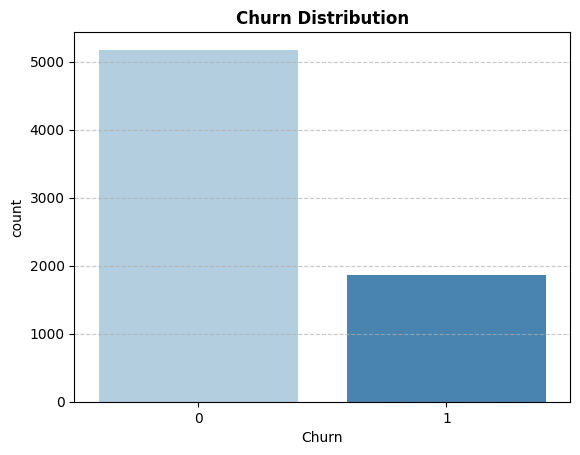

In [36]:
sns.countplot(x="Churn", data=df,palette="Blues")
plt.title("Churn Distribution", fontsize=12, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Tenure vs Churn

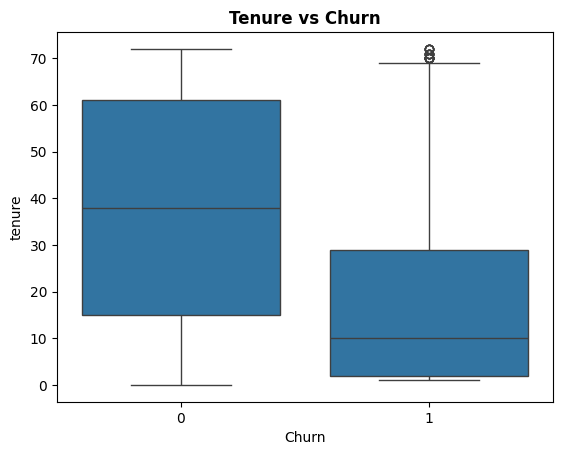

In [38]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn", fontsize=12, fontweight="bold")
plt.show()

Monthly Charges

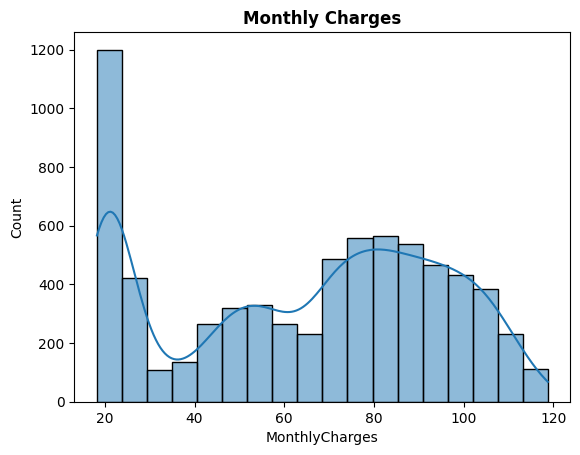

In [39]:
sns.histplot(df["MonthlyCharges"], kde=True)
plt.title("Monthly Charges", fontsize=12, fontweight="bold")
plt.show()

## Data Preprocessing
Data cleaning, handling missing values, and encoding categorical variables.

In [13]:
df.drop("customerID", axis=1, inplace=True)

In [14]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
#converting total charges to numeric

/tmp/ipython-input-224/1207512617.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [15]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

## Feature Selection

The dataset is divided into independent variables (features) and dependent variable (target).
The target variable is **Churn**.

In [16]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training

We train machine learning models to predict customer churn.

**Logistic Regression**

In [18]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
print("Accuracy:", accuracy_score(y_test, pred_lr))

Accuracy: 0.8161816891412349


**K-Nearest Neighbors**

In [20]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

In [21]:
print("KNN Accuracy:", accuracy_score(y_test, pred_knn))

KNN Accuracy: 0.7778566359119943


**Decision Tree**

In [22]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

In [23]:
print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))

Decision Tree Accuracy: 0.7338537970191625


**Random Forest**

In [24]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [25]:
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

Random Forest Accuracy: 0.7963094393186657


**Support Vector Machine**

In [26]:
svm = SVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

In [27]:
print("SVM Accuracy:", accuracy_score(y_test, pred_svm))

SVM Accuracy: 0.7352732434350603


**Gradient Boosting**

In [28]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)

In [29]:
print("Gradient Boosting Accuracy:", accuracy_score(y_test, pred_gb))

Gradient Boosting Accuracy: 0.8055358410220014


# Model Comparison Table

In [30]:
results = pd.DataFrame({
    "Model": ["Logistic", "KNN", "Decision Tree", "Random Forest", "SVM", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_knn),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_svm),
        accuracy_score(y_test, pred_gb)
    ]
})
results

,Model,Accuracy
0,Logistic,0.816182
1,KNN,0.777857
2,Decision Tree,0.733854
3,Random Forest,0.796309
4,SVM,0.735273
5,Gradient Boosting,0.805536


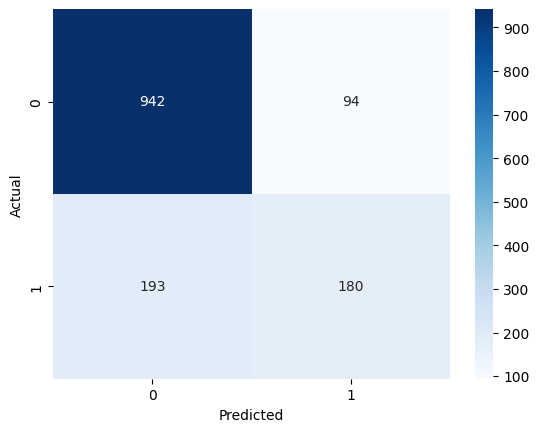

In [31]:
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.56       373

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.80      0.79      1409



## Conclusion

Multiple classification algorithms were applied to predict telecom customer churn.
Among all models, Random Forest and Gradient Boosting provided the highest accuracy.

This project demonstrates how machine learning can help telecom companies
identify customers who are likely to churn and improve customer retention strategies.